# 01 青空文庫 — データ取得・前処理・Word2Vec学習

**このノートブックの目的**

1. 青空文庫から孤独関連テキストを収集する
2. MeCab（fugashi）で形態素解析・トークナイズする
3. Word2Vecモデルを学習する
4. 孤独関連語の意味空間を可視化する

**分析の問い（Phase 1）**
- 「孤独」「孤立」「孤高」はどんな語と共起しているか？
- 時代（明治 / 大正 / 昭和）で意味空間は変わるか？
- Loneliness / Isolation / Solitude の方向ベクトルはデータから確認できるか？

---
> **注意**：青空文庫のテキストは著作権切れ作品が中心（概ね没後70年）。
> 明治〜昭和中期が主なカバー範囲になる。

---
## セッションが切れた場合の再開手順
1. 「ランタイム → すべてのセルを実行」で上から流し直す
2. ダウンロード済みの場合はparquetから読み込むのでスキップされる
3. Google Driveのデータは保持されるので再ダウンロード不要

## 0-A. Google Driveのマウント
データをGoogle Driveに保存することでセッションが切れてもデータが消えない。

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# データ保存先をGoogle Driveに設定
DATA_DIR = Path('/content/drive/MyDrive/loneliness-research-data')
RAW_DIR = DATA_DIR / 'raw' / 'aozora'
PROCESSED_DIR = DATA_DIR / 'processed' / 'aozora'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Google Drive マウント完了')
print(f'データ保存先: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive マウント完了
データ保存先: /content/drive/MyDrive/loneliness-research-data


## 0-B. 環境セットアップ

In [2]:
# ライブラリのインストール（Colab用）
!pip install fugashi unidic-lite gensim umap-learn japanize-matplotlib jaconv -q
print('インストール完了')

インストール完了


In [3]:
import os
import re
import gc
import time
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

import fugashi
import jaconv
from gensim.models import Word2Vec

# 再現性のためシードを固定
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('セットアップ完了')
print(f'  データ保存先: {RAW_DIR}')

セットアップ完了
  データ保存先: /content/drive/MyDrive/loneliness-research-data/raw/aozora


---
## 1. 青空文庫からテキストを取得する

In [4]:
# 青空文庫の作品リスト（CSV）を取得する
CATALOG_URL = 'https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip'
CATALOG_ZIP = RAW_DIR / 'catalog.zip'
CATALOG_CSV = RAW_DIR / 'list_person_all_extended_utf8.csv'

if not CATALOG_CSV.exists():
    print('作品リストをダウンロード中...')
    urllib.request.urlretrieve(CATALOG_URL, CATALOG_ZIP)
    with zipfile.ZipFile(CATALOG_ZIP, 'r') as zf:
        zf.extractall(RAW_DIR)
    print('完了')
else:
    print('作品リストは取得済み')

df_catalog = pd.read_csv(CATALOG_CSV, encoding='utf-8')
print(f'総作品数: {len(df_catalog):,}')

作品リストは取得済み
総作品数: 19,456


In [5]:
# 時代ラベルを付与する
def assign_era(birth_date_str):
    """生年月日から時代ラベルを返す"""
    try:
        year = int(str(birth_date_str)[:4])
        if year < 1868:
            return '江戸以前'
        elif year < 1900:
            return '明治'
        elif year < 1912:
            return '明治後期〜大正'
        elif year < 1926:
            return '大正〜昭和初期'
        elif year < 1945:
            return '昭和戦前'
        else:
            return '昭和戦後以降'
    except:
        return '不明'

df_catalog['era'] = df_catalog['生年月日'].apply(assign_era)
print(df_catalog['era'].value_counts())

era
明治         12459
明治後期〜大正     3597
江戸以前        1970
大正〜昭和初期      665
不明           398
昭和戦後以降       231
昭和戦前         136
Name: count, dtype: int64


In [6]:
# カラム名を確定版で設定
TEXT_URL_COL = 'テキストファイルURL'
TITLE_COL = '作品名'
AUTHOR_COL = '姓'

# テキストURLがあり、江戸以前と不明を除いた作品に絞る
df_target = df_catalog[
    df_catalog[TEXT_URL_COL].notna() &
    (~df_catalog['era'].isin(['不明', '江戸以前']))
].copy()

print(f'対象作品数: {len(df_target):,}')
print(df_target['era'].value_counts())

対象作品数: 16,863
era
明治         12445
明治後期〜大正     3579
大正〜昭和初期      651
昭和戦後以降       114
昭和戦前          74
Name: count, dtype: int64


In [7]:
# テキストをダウンロード・クリーニングする関数
def download_aozora_text(url, save_path):
    try:
        tmp_zip = str(save_path) + '.zip'
        urllib.request.urlretrieve(url, tmp_zip)
        with zipfile.ZipFile(tmp_zip, 'r') as zf:
            txt_files = [f for f in zf.namelist() if f.endswith('.txt')]
            if not txt_files:
                return None
            with zf.open(txt_files[0]) as f:
                try:
                    content = f.read().decode('shift-jis')
                except:
                    content = f.read().decode('utf-8', errors='ignore')
        os.remove(tmp_zip)
        return content
    except Exception as e:
        print(f'  エラー: {e}')
        return None


def clean_aozora_text(text):
    if text is None:
        return ''
    if '-------' in text:
        text = text.split('-------')[-1]
    text = re.sub(r'《[^》]*》', '', text)
    text = re.sub(r'［＃[^］]*］', '', text)
    text = re.sub(r'｜', '', text)
    text = jaconv.z2h(text, kana=False, ascii=True, digit=True)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


print('関数定義完了')

関数定義完了


In [8]:
# 保存済みデータを読み込む（ダウンロード済みの場合はスキップ）
parquet_path = PROCESSED_DIR / 'corpus_full.parquet'

if parquet_path.exists():
    df_corpus_full = pd.read_parquet(parquet_path)
    print(f'保存済みデータを読み込みました: {len(df_corpus_full)}作品')
    print(df_corpus_full['era'].value_counts())
else:
    # 初回のみダウンロード実行（20〜30分かかる）
    ERA_LIMITS = {
        '明治':         200,
        '明治後期〜大正': 200,
        '大正〜昭和初期': 200,
        '昭和戦前':      74,
        '昭和戦後以降':  114,
    }
    df_full = (
        df_target
        .groupby('era', group_keys=False)
        .apply(lambda x: x.sample(
            min(ERA_LIMITS.get(x.name, len(x)), len(x)),
            random_state=RANDOM_SEED
        ), include_groups=False)
    )
    print(f'取得予定: {len(df_full)}作品')

    corpus_full = []
    errors = []
    for i, row in df_full.iterrows():
        url = row[TEXT_URL_COL]
        era = row['era']
        title = row[TITLE_COL]
        author = row[AUTHOR_COL]
        text = download_aozora_text(url, RAW_DIR / f'{i}.txt')
        cleaned = clean_aozora_text(text)
        if cleaned and len(cleaned) > 500:
            corpus_full.append({'text': cleaned, 'era': era, 'title': title, 'author': author})
        else:
            errors.append(title)
        time.sleep(0.3)

    print(f'取得完了: {len(corpus_full)}作品 / スキップ: {len(errors)}作品')
    df_corpus_full = pd.DataFrame(corpus_full)
    df_corpus_full.to_parquet(parquet_path, index=False)
    print('保存完了')

保存済みデータを読み込みました: 694作品
era
明治         192
明治後期〜大正    184
大正〜昭和初期    152
昭和戦後以降     102
昭和戦前        64
Name: count, dtype: int64


---
## 2. 形態素解析・トークナイズ

In [9]:
# 形態素解析の設定
tagger = fugashi.Tagger()
TARGET_POS = {'名詞', '動詞', '形容詞', '副詞'}

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        if len(token) < 2 or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences

# 動作確認
test_text = '彼は孤独を感じていた。その孤立した日々の中で、ひとり静かに書き続けた。'
print('テスト結果:')
for sent in tokenize(test_text):
    print(' ', sent)

テスト結果:
  ['孤独', '感ずる', '居る']
  ['孤立', '為る', '日々', '一人', '書く', '続ける']


In [10]:
import pickle

# 全量コーパスで形態素解析（都度保存でメモリ節約）
SENTENCES_PATH = PROCESSED_DIR / 'sentences_full.pkl'
ERA_SENTENCES_PATH = PROCESSED_DIR / 'era_sentences_full.pkl'

if SENTENCES_PATH.exists() and ERA_SENTENCES_PATH.exists():
    print('トークナイズ済みデータを読み込み中...')
    with open(SENTENCES_PATH, 'rb') as f:
        all_sentences_full = pickle.load(f)
    with open(ERA_SENTENCES_PATH, 'rb') as f:
        era_sentences_full = pickle.load(f)
    print(f'読み込み完了: 総文数 {len(all_sentences_full):,}')
else:
    print('トークナイズ開始...')
    all_sentences_full = []
    era_sentences_full = {}

    BATCH_SIZE = 20  # 小さくしてメモリ節約

    for batch_start in range(0, len(df_corpus_full), BATCH_SIZE):
        batch = df_corpus_full.iloc[batch_start:batch_start + BATCH_SIZE]
        for _, row in batch.iterrows():
            # テキストを段落単位に分割して一度に処理する量を減らす
            paragraphs = row['text'].split('\n\n')
            for para in paragraphs:
                if len(para) < 10:
                    continue
                sentences = tokenize(para)
                all_sentences_full.extend(sentences)
                era = row['era']
                if era not in era_sentences_full:
                    era_sentences_full[era] = []
                era_sentences_full[era].extend(sentences)
        gc.collect()
        print(f'  {min(batch_start + BATCH_SIZE, len(df_corpus_full))} / {len(df_corpus_full)}作品処理済み')

    # 処理完了後に保存
    print('保存中...')
    with open(SENTENCES_PATH, 'wb') as f:
        pickle.dump(all_sentences_full, f)
    with open(ERA_SENTENCES_PATH, 'wb') as f:
        pickle.dump(era_sentences_full, f)
    print('保存完了')

print(f'\n総文数: {len(all_sentences_full):,}')
for era, sents in sorted(era_sentences_full.items()):
    print(f'  {era}: {len(sents):,}文')

トークナイズ開始...
  20 / 694作品処理済み
  40 / 694作品処理済み
  60 / 694作品処理済み
  80 / 694作品処理済み
  100 / 694作品処理済み
  120 / 694作品処理済み
  140 / 694作品処理済み
  160 / 694作品処理済み
  180 / 694作品処理済み
  200 / 694作品処理済み
  220 / 694作品処理済み
  240 / 694作品処理済み
  260 / 694作品処理済み
  280 / 694作品処理済み
  300 / 694作品処理済み
  320 / 694作品処理済み
  340 / 694作品処理済み
  360 / 694作品処理済み
  380 / 694作品処理済み
  400 / 694作品処理済み
  420 / 694作品処理済み
  440 / 694作品処理済み
  460 / 694作品処理済み
  480 / 694作品処理済み
  500 / 694作品処理済み
  520 / 694作品処理済み
  540 / 694作品処理済み
  560 / 694作品処理済み
  580 / 694作品処理済み
  600 / 694作品処理済み
  620 / 694作品処理済み
  640 / 694作品処理済み
  660 / 694作品処理済み
  680 / 694作品処理済み
  694 / 694作品処理済み
保存中...
保存完了

総文数: 225,305
  大正〜昭和初期: 27,687文
  明治: 52,077文
  明治後期〜大正: 36,652文
  昭和戦前: 60,059文
  昭和戦後以降: 48,830文


---
## 3. Word2Vecモデルの学習

In [11]:
W2V_PARAMS = dict(
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    epochs=10,
    workers=4,
    seed=RANDOM_SEED,
)

print('Word2Vec学習中...')
model = Word2Vec(sentences=all_sentences_full, **W2V_PARAMS)
print(f'語彙数: {len(model.wv):,}')
model.save(str(PROCESSED_DIR / 'w2v_aozora_all.model'))
print('モデル保存完了')

Word2Vec学習中...
語彙数: 35,184
モデル保存完了


In [12]:
# 孤独関連語の類似語を確認
SEED_WORDS = ['孤独', '孤立', '孤高', '寂しい', 'ひとり', '一人']

for word in SEED_WORDS:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=10)
        print(f'\n【{word}】に近い語:')
        for w, score in similar:
            print(f'  {w:10s}  {score:.3f}')
    else:
        print(f'\n【{word}】: 語彙になし')


【孤独】に近い語:
  天涯          0.806
  悲哀          0.783
  世俗          0.738
  隣人          0.726
  罪悪          0.725
  情欲          0.713
  味気無い        0.707
  憧憬          0.704
  離散          0.703
  虚妄          0.701

【孤立】に近い語:
  活力          0.813
  倍増          0.812
  蹂躙          0.802
  萌芽          0.801
  対峙          0.801
  打開          0.798
  媒介          0.798
  人為          0.796
  根強い         0.795
  増殖          0.794

【孤高】に近い語:
  開眼          0.932
  オルソドックス     0.930
  習癖          0.928
  詩論          0.927
  ユウェナリス      0.922
  生育          0.922
  ドウーゼ        0.918
  審美          0.914
  堕する         0.913
  スカンジナビア-Scandinavia  0.912

【寂しい】に近い語:
  侘しい         0.697
  うらぶれる       0.694
  恋しい         0.670
  心細い         0.653
  悲しい         0.637
  微笑ましい       0.632
  慰む          0.630
  飛び歩く        0.628
  晴々          0.623
  独りぼっち       0.621

【ひとり】: 語彙になし

【一人】に近い語:
  ポリネシア-Polynesia  0.549
  馬番          0.532
  ミタニ         0.508
  年輩          0.502
  初老          0.500
  多く          0.

---
## 4. 孤独語の意味空間を可視化する（UMAP）

In [13]:
# 三分類のSeed語彙
LONELINESS_SEEDS = ['孤独', '寂しい', '悲しい', '虚しい', '空虚', '疎外', '取り残す', '心細い']
ISOLATION_SEEDS  = ['孤立', '断絶', '疎遠', '引きこもる', '排除', '遠ざかる', '孤立無援']
SOLITUDE_SEEDS   = ['孤高', '独り', '静かだ', '自由', '内省', '沈黙', '一人']
CONNECTION_SEEDS = ['友人', '家族', '絆', 'つながる', '仲間', '集う', '愛する']

def filter_vocab(words, model):
    return [w for w in words if w in model.wv]

loneliness_words = filter_vocab(LONELINESS_SEEDS, model)
isolation_words  = filter_vocab(ISOLATION_SEEDS, model)
solitude_words   = filter_vocab(SOLITUDE_SEEDS, model)
connection_words = filter_vocab(CONNECTION_SEEDS, model)

print('可視化対象語数:')
print(f'  Loneliness: {len(loneliness_words)} → {loneliness_words}')
print(f'  Isolation:  {len(isolation_words)} → {isolation_words}')
print(f'  Solitude:   {len(solitude_words)} → {solitude_words}')
print(f'  Connection: {len(connection_words)} → {connection_words}')

可視化対象語数:
  Loneliness: 7 → ['孤独', '寂しい', '悲しい', '空虚', '疎外', '取り残す', '心細い']
  Isolation:  4 → ['孤立', '断絶', '排除', '遠ざかる']
  Solitude:   6 → ['孤高', '独り', '自由', '内省', '沈黙', '一人']
  Connection: 5 → ['友人', '家族', '仲間', '集う', '愛する']


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


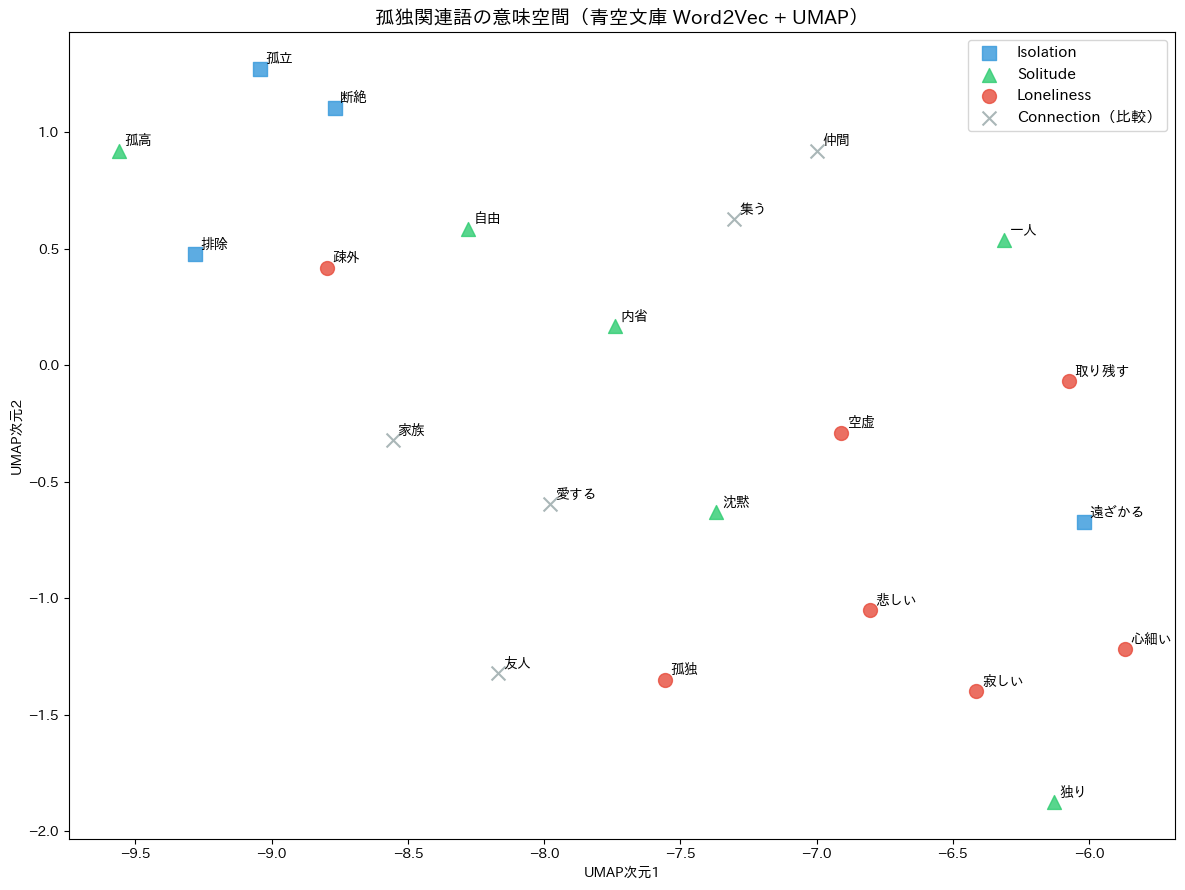

図を保存しました


In [14]:
import umap.umap_ as umap

viz_words = loneliness_words + isolation_words + solitude_words + connection_words
viz_labels = (
    ['Loneliness'] * len(loneliness_words) +
    ['Isolation']  * len(isolation_words) +
    ['Solitude']   * len(solitude_words) +
    ['Connection（比較）'] * len(connection_words)
)

vectors = np.array([model.wv[w] for w in viz_words])

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(10, len(viz_words)-1),
    random_state=RANDOM_SEED,
    metric='cosine'
)
embedding = reducer.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(12, 9))
COLORS  = {'Loneliness': '#E74C3C', 'Isolation': '#3498DB', 'Solitude': '#2ECC71', 'Connection（比較）': '#95A5A6'}
MARKERS = {'Loneliness': 'o',       'Isolation': 's',       'Solitude': '^',       'Connection（比較）': 'x'}

for label in set(viz_labels):
    idx = [i for i, l in enumerate(viz_labels) if l == label]
    ax.scatter(embedding[idx, 0], embedding[idx, 1],
               c=COLORS[label], marker=MARKERS[label], s=100, label=label, alpha=0.8)

for i, (word, label) in enumerate(zip(viz_words, viz_labels)):
    ax.annotate(word, (embedding[i, 0], embedding[i, 1]),
                fontsize=10, textcoords='offset points', xytext=(4, 4))

ax.legend(fontsize=11)
ax.set_title('孤独関連語の意味空間（青空文庫 Word2Vec + UMAP）', fontsize=14)
ax.set_xlabel('UMAP次元1')
ax.set_ylabel('UMAP次元2')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'umap_loneliness_words.png', dpi=150)
plt.show()
print('図を保存しました')

---
## 5. 方向ベクトルの試作（Loneliness / Isolation / Solitude 軸）

In [15]:
from numpy.linalg import norm

def make_axis_vector(seed_words, model):
    vecs = [model.wv[w] for w in seed_words if w in model.wv]
    if not vecs:
        return None
    axis = np.mean(vecs, axis=0)
    return axis / norm(axis)

def score_on_axis(word, axis_vector, model):
    if word not in model.wv or axis_vector is None:
        return None
    wv = model.wv[word]
    return float(np.dot(wv, axis_vector) / (norm(wv) * norm(axis_vector)))

axis_loneliness = make_axis_vector(loneliness_words, model)
axis_isolation  = make_axis_vector(isolation_words, model)
axis_solitude   = make_axis_vector(solitude_words, model)

print('軸ベクトル作成完了')
print(f'  Loneliness軸: {len(loneliness_words)}語から')
print(f'  Isolation軸:  {len(isolation_words)}語から')
print(f'  Solitude軸:   {len(solitude_words)}語から')

軸ベクトル作成完了
  Loneliness軸: 7語から
  Isolation軸:  4語から
  Solitude軸:   6語から


In [16]:
# 孤独周辺語を3軸でスコアリング
TARGET_WORDS_FOR_SCORING = [
    '孤独', '孤立', '孤高', '寂しい', '独り', '一人',
    '悲しい', '自由', '静かだ', '断絶', '友人', '家族', '愛する',
    '夜', '部屋', '窓', '海', '空'
]

rows = []
for word in TARGET_WORDS_FOR_SCORING:
    if word not in model.wv:
        continue
    rows.append({
        'word': word,
        'Loneliness': score_on_axis(word, axis_loneliness, model),
        'Isolation':  score_on_axis(word, axis_isolation, model),
        'Solitude':   score_on_axis(word, axis_solitude, model),
    })

df_scores = pd.DataFrame(rows).set_index('word')
print(df_scores.round(3).to_string())

      Loneliness  Isolation  Solitude
word                                 
孤独         0.831      0.565     0.648
孤立         0.598      0.878     0.626
孤高         0.628      0.741     0.680
寂しい        0.797      0.460     0.528
独り         0.590      0.446     0.673
一人         0.399      0.331     0.568
悲しい        0.787      0.454     0.537
自由         0.347      0.432     0.634
断絶         0.491      0.777     0.644
友人         0.360      0.299     0.424
家族         0.528      0.449     0.490
愛する        0.557      0.473     0.544
部屋         0.338      0.286     0.356


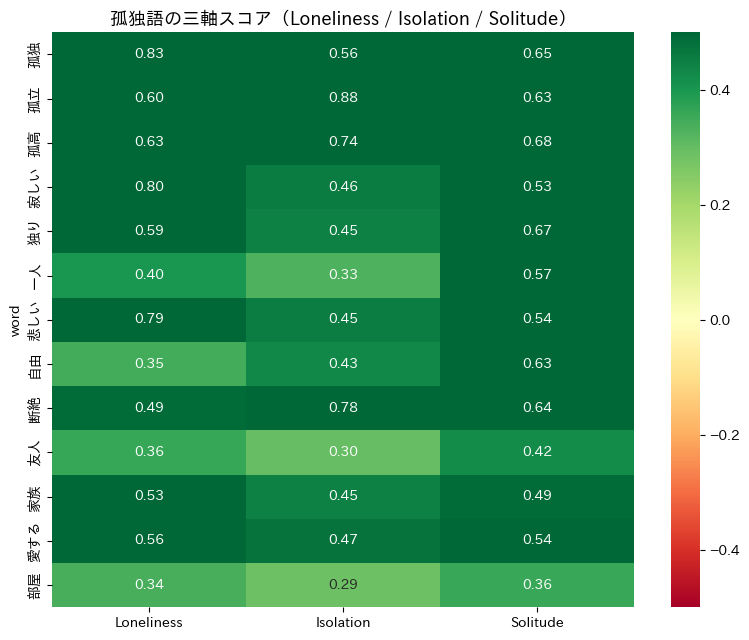

In [17]:
# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(8, max(4, len(df_scores) * 0.5)))
sns.heatmap(df_scores, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title('孤独語の三軸スコア（Loneliness / Isolation / Solitude）', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'axis_scores_heatmap.png', dpi=150)
plt.show()

---
## 6. 時代別比較

In [18]:
# 時代別モデルを学習
era_models = {}

for era, sents in sorted(era_sentences_full.items()):
    if len(sents) < 100:
        print(f'[{era}] データ不足でスキップ ({len(sents)}文)')
        continue
    print(f'[{era}] 学習中... ({len(sents):,}文)', end='')
    m = Word2Vec(sentences=sents, **W2V_PARAMS)
    era_models[era] = m
    print(f' 完了（語彙数: {len(m.wv):,}）')

print(f'\n学習済み時代: {list(era_models.keys())}')

[大正〜昭和初期] 学習中... (27,687文) 完了（語彙数: 9,780）
[明治] 学習中... (52,077文) 完了（語彙数: 17,588）
[明治後期〜大正] 学習中... (36,652文) 完了（語彙数: 13,432）
[昭和戦前] 学習中... (60,059文) 完了（語彙数: 12,108）
[昭和戦後以降] 学習中... (48,830文) 完了（語彙数: 13,386）

学習済み時代: ['大正〜昭和初期', '明治', '明治後期〜大正', '昭和戦前', '昭和戦後以降']


In [19]:
# 時代別の「孤独」類似語比較
FOCUS_WORD = '孤独'

for era, m in sorted(era_models.items()):
    if FOCUS_WORD in m.wv:
        similar = m.wv.most_similar(FOCUS_WORD, topn=10)
        print(f'\n【{era}】「{FOCUS_WORD}」に近い語:')
        for w, s in similar:
            print(f'  {w:12s} {s:.3f}')
    else:
        print(f'\n【{era}】「{FOCUS_WORD}」は語彙になし')


【大正〜昭和初期】「孤独」に近い語:
  感覚           0.934
  感傷           0.929
  解放           0.922
  事実           0.910
  境遇           0.908
  悩む           0.904
  得体           0.904
  出来事          0.904
  宿命           0.902
  日常           0.901

【明治】「孤独」に近い語:
  聡明           0.941
  痛切           0.938
  愛着           0.928
  宿命           0.927
  感傷           0.923
  嫉妬           0.921
  傍観           0.916
  英知           0.916
  公子           0.915
  余裕           0.915

【明治後期〜大正】「孤独」に近い語:
  感傷           0.933
  耐える          0.900
  捕らわれる        0.890
  愛人           0.886
  悲哀           0.879
  見出だす         0.878
  冷酷           0.878
  綱渡り          0.877
  強める          0.876
  運命           0.875

【昭和戦前】「孤独」に近い語:
  苦悩           0.870
  妄想           0.857
  野心           0.856
  夢見る          0.853
  振る舞う         0.845
  悲しみ          0.839
  不潔           0.837
  卑劣           0.837
  騙す           0.836
  崇高           0.833

【昭和戦後以降】「孤独」に近い語:
  寒気           0.955
  盛る           0.950
  抱き留める        0.949
  寄せ合う

---
## メモ・気づき

（このセルに分析中の気づき・疑問点を随時記録する）

-
-

## 次のステップ

- [ ] BCCWJが届いたら同じパイプラインを適用
- [ ] Sentence-BERT に切り替えて文レベル分析
- [ ] 孤独語を含む文の抽出・クラスタリング